In [1]:
#This notebook is about Random Forest Regression. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("income_evaluation.csv")
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.shape

(32561, 15)

In [5]:
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

In [6]:
col_names=["age","workclass","finalweight", "education","education_num","marital_status","occapation","relationship","race","sex","capital_gain","capital_loss","hours_per_week","native_country","income"]
df.columns=col_names
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occapation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [7]:
df.describe()

,age,finalweight,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
for col in df.columns:
    if df[col].dtype=="O":
        print(col)

workclass
education
marital_status
occapation
relationship
race
sex
native_country
income


In [9]:
categorical_cols=[col for col in df.columns if df[col].dtype=="O"]
numerical_cols=[col for col in df.columns if df[col].dtype!="O"]

In [10]:
for col in categorical_cols:
    print(df[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occapation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

In [11]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

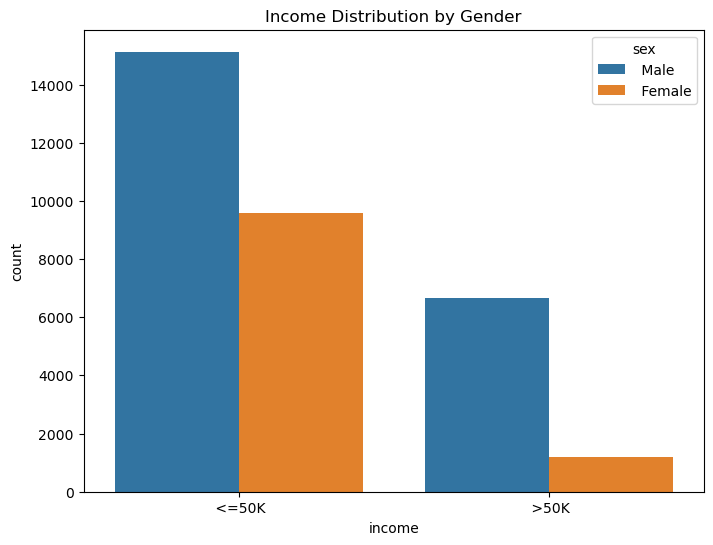

In [12]:
fig,ax = plt.subplots(figsize=(8,6))
ax=sns.countplot(x="income",hue="sex", data=df)
ax.set_title("Income Distribution by Gender")
plt.show()

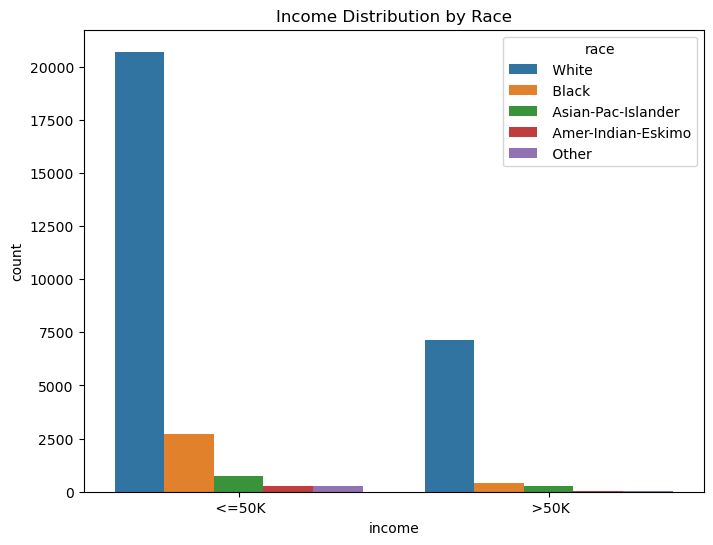

In [13]:
fig,ax = plt.subplots(figsize=(8,6))
ax=sns.countplot(x="income",hue="race", data=df)
ax.set_title("Income Distribution by Race")
plt.show()

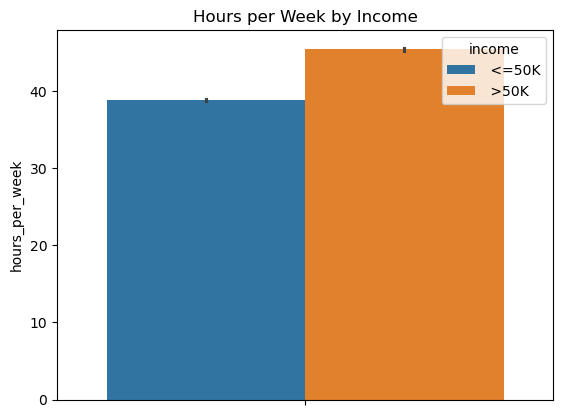

In [14]:
sns.barplot(y=df["hours_per_week"],hue=df["income"])
plt.title("Hours per Week by Income")    
plt.show()

In [15]:
df["workclass"].unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [16]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [17]:
df["workclass"]=df["workclass"].replace(" ?",np.nan)
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [18]:
df["education"].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [19]:
df["marital_status"].unique()   

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [20]:
df["occapation"].unique()   

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [21]:
df["occapation"]=df["occapation"].replace(" ?",np.nan)
df["occapation"].value_counts()

occapation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [22]:
df["relationship"].unique()

array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

In [23]:
df["sex"].unique()

array([' Male', ' Female'], dtype=object)

In [24]:
df["race"].unique()

array([' White', ' Black', ' Asian-Pac-Islander', ' Amer-Indian-Eskimo',
       ' Other'], dtype=object)

In [25]:
df["native_country"].unique()   

array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [26]:
df["native_country"]=df["native_country"].replace(" ?",np.nan)
df["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [27]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occapation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

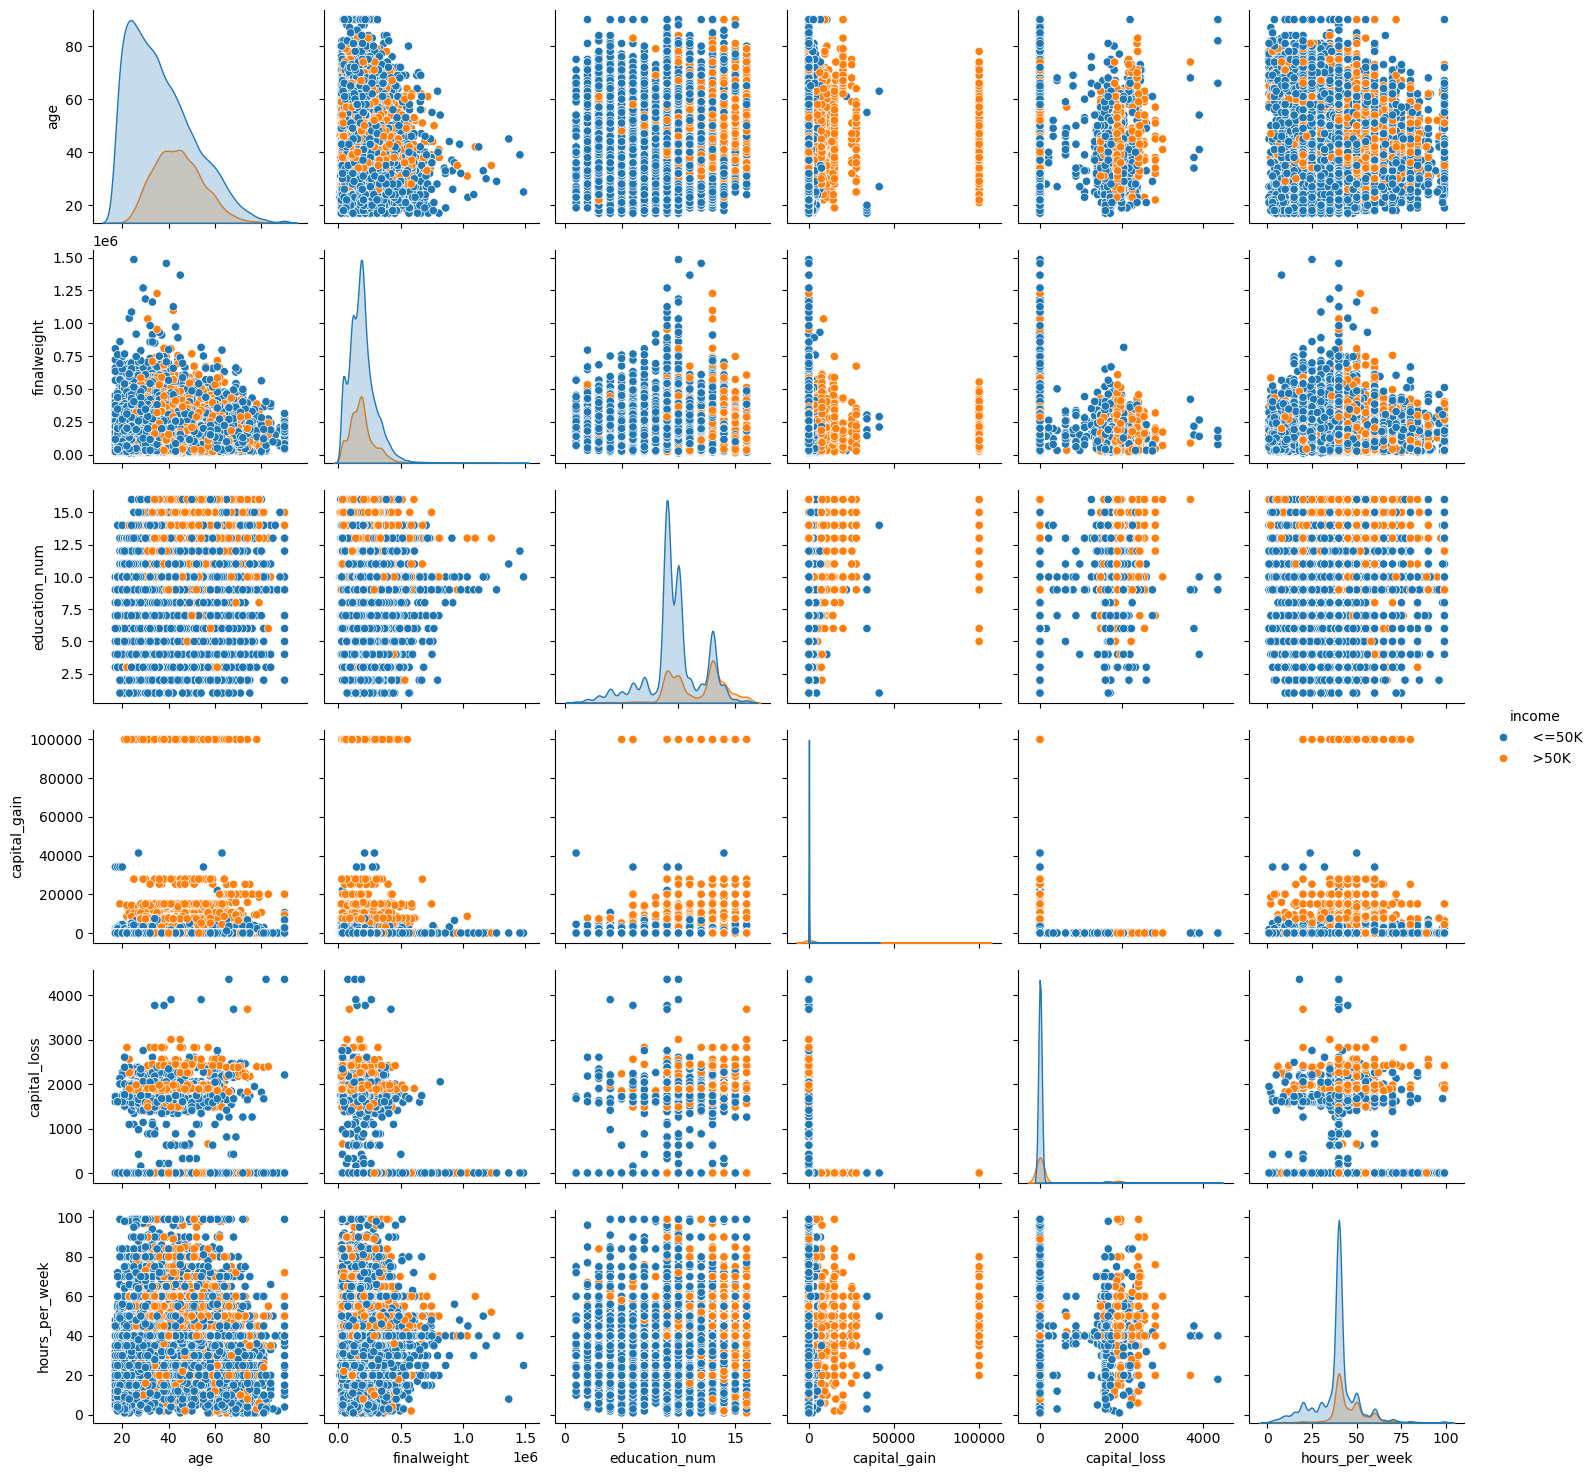

In [28]:
sns.pairplot(df,hue="income")
plt.show()

In [29]:
X=df.drop("income",axis=1)
y=df["income"]

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=34)

In [31]:
categorical=[col for col in X_train.columns if X_train[col].dtype=="O"]
X_train[categorical].isnull().sum()

workclass         1267
education            0
marital_status       0
occapation        1272
relationship         0
race                 0
sex                  0
native_country     393
dtype: int64

In [32]:
X_test[categorical].isnull().sum()

workclass         569
education           0
marital_status      0
occapation        571
relationship        0
race                0
sex                 0
native_country    190
dtype: int64

In [33]:
#replace with mode
for i in [X_train,X_test]:
    for col in categorical:
        i[col]=i[col].fillna(i[col].mode()[0])

In [34]:
X_train.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occapation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [35]:
X_test.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occapation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64

In [36]:
#Encoding
y_train_binary=y_train.apply(lambda x: 1 if x.strip()=='>50K' else 0)
target_means=y_train_binary.groupby(X_train['native_country']).mean()

In [42]:
X_train['native_country_encoded']=X_train['native_country'].map(target_means)
X_train['native_country_encoded']=X_train['native_country_encoded'].fillna(y_train_binary.mean())
X_test['native_country_encoded']=X_test['native_country'].map(target_means)
X_test['native_country_encoded']=X_test['native_country_encoded'].fillna(y_train_binary.mean())

In [43]:
X_train.head(10)

,age,workclass,finalweight,education,education_num,marital_status,occapation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
16021,22,Private,112130,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Female,0,0,40,United-States,0.243736
11632,57,Private,161097,HS-grad,9,Divorced,Sales,Not-in-family,White,Female,0,0,26,United-States,0.243736
17727,27,Local-gov,199471,Assoc-voc,11,Never-married,Tech-support,Own-child,White,Female,0,0,38,United-States,0.243736
12418,31,Private,297188,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,60,United-States,0.243736
8691,48,Local-gov,189762,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0.243736
9831,67,Private,35015,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,99,United-States,0.243736
16425,59,Private,113203,HS-grad,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,0.243736
2362,36,Private,183892,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,44,United-States,0.243736
333,55,Local-gov,98545,10th,6,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,0.243736
7187,67,Self-emp-not-inc,226092,Some-college,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,44,United-States,0.243736


In [44]:
X_train=X_train.drop("native_country", axis=1)
X_test=X_test.drop("native_country", axis=1)

In [45]:
categorical

['workclass',
 'education',
 'marital_status',
 'occapation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [46]:
one_hot_categories=['workclass',
 'education',
 'marital_status',
 'occapation',
 'relationship',
 'race',
 'sex']

In [48]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [53]:
encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore",sparse_output=False),one_hot_categories)
    ], remainder="passthrough"
)

In [54]:
X_train_enc=encoder.fit_transform(X_train)
X_test_enc=encoder.transform(X_test)

In [55]:
X_train_enc

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24373587],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        26.        ,  0.24373587],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        38.        ,  0.24373587],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24373587],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        80.        ,  0.24373587],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        60.        ,  0.24373587]])

In [56]:
# get all encoded column names
columns = encoder.get_feature_names_out()
columns

array(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Never-worked', 'cat__workclass_ Private',
       'cat__workclass_ Self-emp-inc', 'cat__workclass_ Self-emp-not-inc',
       'cat__workclass_ State-gov', 'cat__workclass_ Without-pay',
       'cat__education_ 10th', 'cat__education_ 11th',
       'cat__education_ 12th', 'cat__education_ 1st-4th',
       'cat__education_ 5th-6th', 'cat__education_ 7th-8th',
       'cat__education_ 9th', 'cat__education_ Assoc-acdm',
       'cat__education_ Assoc-voc', 'cat__education_ Bachelors',
       'cat__education_ Doctorate', 'cat__education_ HS-grad',
       'cat__education_ Masters', 'cat__education_ Preschool',
       'cat__education_ Prof-school', 'cat__education_ Some-college',
       'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-AF-spouse',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-mar

In [57]:
X_train = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
16021,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,22.0,112130.0,9.0,0.0,0.0,40.0,0.243736
11632,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,57.0,161097.0,9.0,0.0,0.0,26.0,0.243736
17727,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,27.0,199471.0,11.0,0.0,0.0,38.0,0.243736
12418,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,31.0,297188.0,14.0,0.0,0.0,60.0,0.243736
8691,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,48.0,189762.0,9.0,0.0,0.0,40.0,0.243736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28406,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,66.0,28061.0,4.0,0.0,0.0,50.0,0.243736
22377,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,37.0,160035.0,9.0,0.0,0.0,40.0,0.243736
10730,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,42.0,31621.0,12.0,0.0,0.0,40.0,0.243736
5242,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,35.0,82622.0,10.0,0.0,0.0,80.0,0.243736


In [58]:
X_test

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
9217,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,47.0,212120.0,13.0,0.0,0.0,45.0,0.243736
17355,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,27.0,238859.0,11.0,0.0,0.0,40.0,0.243736
12279,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,29.0,219906.0,13.0,0.0,0.0,25.0,0.243736
22843,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,59.0,99131.0,9.0,0.0,0.0,40.0,0.243736
4314,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,48.0,177775.0,9.0,0.0,0.0,40.0,0.243736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16054,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,42.0,160369.0,9.0,0.0,0.0,40.0,0.243736
28650,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,38.0,122076.0,10.0,7298.0,0.0,43.0,0.243736
2626,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,52.0,30731.0,9.0,7298.0,0.0,40.0,0.243736
30546,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,47.0,45564.0,10.0,0.0,0.0,40.0,0.243736


In [59]:
X_train.columns

Index(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Never-worked', 'cat__workclass_ Private',
       'cat__workclass_ Self-emp-inc', 'cat__workclass_ Self-emp-not-inc',
       'cat__workclass_ State-gov', 'cat__workclass_ Without-pay',
       'cat__education_ 10th', 'cat__education_ 11th', 'cat__education_ 12th',
       'cat__education_ 1st-4th', 'cat__education_ 5th-6th',
       'cat__education_ 7th-8th', 'cat__education_ 9th',
       'cat__education_ Assoc-acdm', 'cat__education_ Assoc-voc',
       'cat__education_ Bachelors', 'cat__education_ Doctorate',
       'cat__education_ HS-grad', 'cat__education_ Masters',
       'cat__education_ Preschool', 'cat__education_ Prof-school',
       'cat__education_ Some-college', 'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-AF-spouse',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-married', 

In [60]:
cols = X_train.columns

In [61]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [64]:
# we don't have to convert X_train into df again, we can just give it as a numpy array to model but 
# if we want to use column names again later it will come in handy
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

In [65]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=10, random_state=15)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score
print(f'Model accuracy score with 10 decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with 10 decision-trees : 0.8458388780837343


In [68]:
# instantiate the classifier with n_estimators = 100
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with default decision-trees : 0.8505476507319071


In [69]:
rfc.feature_importances_

array([5.94289719e-03, 5.88818289e-03, 5.68892726e-06, 1.09891265e-02,
       6.26564731e-03, 8.96397305e-03, 4.80633023e-03, 4.64442309e-05,
       1.26510814e-03, 1.73471486e-03, 7.38229822e-04, 1.79326917e-04,
       7.03057861e-04, 1.59144716e-03, 1.02581395e-03, 2.35297134e-03,
       3.15608258e-03, 1.12765213e-02, 3.55778629e-03, 8.57759721e-03,
       7.36042723e-03, 3.22986370e-05, 4.71863690e-03, 5.43028916e-03,
       6.32277742e-03, 4.25706026e-04, 6.41520762e-02, 8.84584554e-04,
       2.58468241e-02, 1.53015033e-03, 1.66915637e-03, 5.88763790e-03,
       7.30005885e-06, 7.07576027e-03, 1.85534683e-02, 4.26990149e-03,
       3.62625899e-03, 4.57757025e-03, 6.79754750e-03, 1.33794967e-04,
       1.06189654e-02, 3.05530837e-03, 7.96123689e-03, 4.93632980e-03,
       5.25031342e-03, 4.15612505e-02, 1.07398101e-02, 1.54301432e-03,
       9.38477497e-03, 4.07433645e-03, 1.04039950e-02, 1.32223884e-03,
       3.45710807e-03, 5.11645199e-03, 8.25487276e-04, 7.03759489e-03,
      

In [70]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)

In [71]:
feature_scores

remainder__finalweight              0.159116
remainder__age                      0.149291
remainder__capital_gain             0.094638
remainder__hours_per_week           0.085936
remainder__education_num            0.070438
                                      ...   
cat__occapation_ Priv-house-serv    0.000134
cat__workclass_ Without-pay         0.000046
cat__education_ Preschool           0.000032
cat__occapation_ Armed-Forces       0.000007
cat__workclass_ Never-worked        0.000006
Length: 65, dtype: float64

In [73]:
pd.set_option('display.float_format', '{:.8f}'.format)
feature_scores

remainder__finalweight             0.15911571
remainder__age                     0.14929113
remainder__capital_gain            0.09463788
remainder__hours_per_week          0.08593636
remainder__education_num           0.07043757
                                      ...    
cat__occapation_ Priv-house-serv   0.00013379
cat__workclass_ Without-pay        0.00004644
cat__education_ Preschool          0.00003230
cat__occapation_ Armed-Forces      0.00000730
cat__workclass_ Never-worked       0.00000569
Length: 65, dtype: float64

In [74]:
feature_scores.tail(10)

cat__race_ Other                         0.00082549
cat__education_ 12th                     0.00073823
cat__education_ 5th-6th                  0.00070306
cat__marital_status_ Married-AF-spouse   0.00042571
cat__education_ 1st-4th                  0.00017933
cat__occapation_ Priv-house-serv         0.00013379
cat__workclass_ Without-pay              0.00004644
cat__education_ Preschool                0.00003230
cat__occapation_ Armed-Forces            0.00000730
cat__workclass_ Never-worked             0.00000569
dtype: float64

In [78]:
X_train = X_train.drop(["cat__workclass_ Never-worked", "cat__occapation_ Armed-Forces","cat__education_ Preschool",
                       "cat__workclass_ Without-pay", "cat__occapation_ Priv-house-serv", "cat__marital_status_ Married-AF-spouse",
                        "cat__education_ 1st-4th", "cat__education_ 5th-6th", "cat__race_ Other", "cat__education_ 12th"
                       ], axis=1)

C:\Users\sudet\AppData\Local\Temp\ipykernel_21556\1319740761.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_train = X_train.drop(["cat__workclass_ Never-worked", "cat__occapation_ Armed-Forces","cat__education_ Preschool",


In [79]:
X_test = X_test.drop(["cat__workclass_ Never-worked", "cat__occapation_ Armed-Forces","cat__education_ Preschool",
                       "cat__workclass_ Without-pay", "cat__occapation_ Priv-house-serv", "cat__marital_status_ Married-AF-spouse",
                        "cat__education_ 1st-4th", "cat__education_ 5th-6th", "cat__race_ Other", "cat__education_ 12th"
                       ], axis=1)

C:\Users\sudet\AppData\Local\Temp\ipykernel_21556\612124715.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  X_test = X_test.drop(["cat__workclass_ Never-worked", "cat__occapation_ Armed-Forces","cat__education_ Preschool",


In [80]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with default decision-trees : 0.8513665677141979


In [81]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[6807  556]
 [ 896 1510]]


In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      7363
        >50K       0.73      0.63      0.68      2406

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [83]:
# Hyperparameter Tuning
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [84]:
from sklearn.model_selection import RandomizedSearchCV

rfc = RandomForestClassifier()
rscv = RandomizedSearchCV(estimator=rfc, param_distributions=rf_params,n_iter=10,cv=3,verbose=2,n_jobs=-1)
rscv.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 8, 15, None, 10],
                                        'max_features': [5, 7, 'auto', 8],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 200, 500, 1000]},
                   verbose=2)

In [85]:
y_pred = rscv.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with default decision-trees : 0.8604770191421844


In [86]:
rscv.best_params_

{'n_estimators': 500,
 'min_samples_split': 20,
 'max_features': 8,
 'max_depth': 15}

In [87]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7363
        >50K       0.79      0.59      0.68      2406

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.86      0.86      0.85      9769



In [88]:
print(confusion_matrix(y_test, y_pred))

[[6988  375]
 [ 988 1418]]
